# Notebook 9: Streamlit Dashboard Preparation

## Objective
This notebook prepares the reusable Python functions, SQL queries, KPIs, filters, and chart logic required for the final Streamlit dashboard.

## Dashboard Goals
- Real-time data exploration
- State/year/quarter filtering
- Transaction, user, and insurance analysis
- Top performers and business insights

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine

In [2]:
user = "root"
password = "12345"
host = "localhost"
port = "3306"
database = "phonepe_insights"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

## KPI Query Functions

In [3]:
def get_overall_kpis():
    total_amount = pd.read_sql("SELECT SUM(transaction_amount) AS total_amount FROM aggregated_transaction", engine)
    total_count = pd.read_sql("SELECT SUM(transaction_count) AS total_count FROM aggregated_transaction", engine)
    total_users = pd.read_sql("SELECT SUM(count) AS total_users FROM aggregated_user", engine)
    total_insurance = pd.read_sql("SELECT SUM(transaction_amount) AS total_insurance FROM aggregated_insurance", engine)
    
    return {
        "total_amount": total_amount.iloc[0, 0],
        "total_count": total_count.iloc[0, 0],
        "total_users": total_users.iloc[0, 0],
        "total_insurance": total_insurance.iloc[0, 0]
    }

get_overall_kpis()

{'total_amount': np.float64(691044589670773.9),
 'total_count': np.float64(470568433748.0),
 'total_users': np.float64(6920650384.0),
 'total_insurance': np.float64(40031156768.0)}

In [4]:
def get_statewise_transactions(year=None, quarter=None):
    query = """
    SELECT state, SUM(transaction_amount) AS total_amount, SUM(transaction_count) AS total_count
    FROM aggregated_transaction
    WHERE 1=1
    """
    if year is not None:
        query += f" AND year = {year}"
    if quarter is not None:
        query += f" AND quarter = {quarter}"
    query += " GROUP BY state ORDER BY total_amount DESC"
    return pd.read_sql(query, engine)

In [5]:
def get_categorywise_transactions(year=None, quarter=None, state=None):
    query = """
    SELECT transaction_type, SUM(transaction_amount) AS total_amount, SUM(transaction_count) AS total_count
    FROM aggregated_transaction
    WHERE 1=1
    """
    if year is not None:
        query += f" AND year = {year}"
    if quarter is not None:
        query += f" AND quarter = {quarter}"
    if state is not None:
        query += f" AND state = '{state}'"
    query += " GROUP BY transaction_type ORDER BY total_amount DESC"
    return pd.read_sql(query, engine)

In [6]:
def get_top_districts(state=None, year=None, quarter=None):
    query = """
    SELECT district, SUM(transaction_amount) AS total_amount
    FROM map_transaction
    WHERE 1=1
    """
    if state is not None:
        query += f" AND state = '{state}'"
    if year is not None:
        query += f" AND year = {year}"
    if quarter is not None:
        query += f" AND quarter = {quarter}"
    query += " GROUP BY district ORDER BY total_amount DESC LIMIT 10"
    return pd.read_sql(query, engine)

In [7]:
def get_user_metrics(state = None, year = None, quarter = None):
    # Where conditions builder
    where_clause = " WHERE 1=1"
    if state is not None: where_clause += f" AND state = '{state}'"
    if year is not None: where_clause += f" AND year = {year}"
    if quarter is not None: where_clause += f" AND quarter = {quarter}"
    
    # Query registered users from aggregated_user
    user_query = f"SELECT state, SUM(count) AS registered_users FROM aggregated_user {where_clause} GROUP BY state"
    df_users = pd.read_sql(user_query, engine)
    
    # Query app opens from map_user
    opens_query = f"SELECT state, SUM(app_opens) AS app_opens FROM map_user {where_clause} GROUP BY state"
    df_opens = pd.read_sql(opens_query, engine)
    
    # Merge them together
    if not df_users.empty and not df_opens.empty:
        return pd.merge(df_users, df_opens, on="state")
    return df_users if not df_users.empty else df_opens

In [8]:
def get_insurance_metrics(state = None, year = None, quarter = None):
    query = """
    SELECT state, 
           SUM(transaction_amount) AS insurance_amount, 
           SUM(transaction_count) AS insurance_count 
    FROM aggregated_insurance 
    WHERE 1=1
    """
    if state is not None:
        query += f" AND state = '{state}'"
    if year is not None:
        query += f" AND year = {year}"
    if quarter is not None:
        query += f" AND quarter = {quarter}"
        
    query += " GROUP BY state ORDER BY insurance_amount DESC"
    return pd.read_sql(query, engine)

## Testing Query Functions

In [9]:
get_statewise_transactions().head()

,state,total_amount,total_count
0,Telangana,8.331191e+13,5.234937e+10
1,Karnataka,8.135744e+13,6.194189e+10
2,Maharashtra,8.074839e+13,6.397042e+10
3,Andhra Pradesh,6.933816e+13,3.783739e+10
4,Uttar Pradesh,5.377042e+13,3.704721e+10


In [10]:
get_categorywise_transactions().head()

,transaction_type,total_amount,total_count
0,Peer-to-peer payments,5.330547e+14,1.700649e+11
1,Merchant payments,1.306798e+14,2.604775e+11
2,Recharge & bill payments,2.667752e+13,3.919351e+10
3,Others,3.485613e+11,5.241004e+08
4,Financial Services,2.840375e+11,3.084179e+08


In [11]:
get_top_districts().head()

,district,total_amount
0,bengaluru urban district,3.987568e+13
1,hyderabad district,2.381387e+13
2,pune district,1.946044e+13
3,jaipur district,1.570818e+13
4,rangareddy district,1.431028e+13


## Plotly Chart Functions

In [12]:
def plot_statewise_amount(df):
    fig = px.bar(df.head(10), x="state", y="total_amount", color="total_amount",
                 title="Top States by Transaction Amount")
    fig.show()

In [13]:
def plot_category_share(df):
    fig = px.pie(df, names="transaction_type", values="total_amount",
                 title="Category-wise Transaction Share")
    fig.show()

In [14]:
def plot_top_districts(df):
    fig = px.bar(df, x="district", y="total_amount", color="total_amount",
                 title="Top Districts by Transaction Amount")
    fig.show()

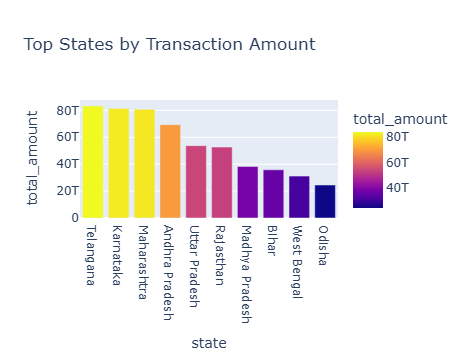

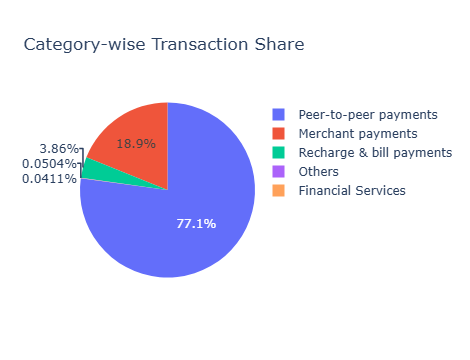

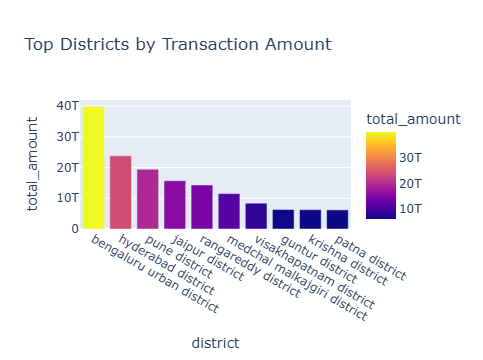

In [15]:
plot_statewise_amount(get_statewise_transactions())
plot_category_share(get_categorywise_transactions())
plot_top_districts(get_top_districts())

## Dashboard Layout Plan

### Sidebar Filters
- Year
- Quarter
- State

### Main Sections
1. KPI Cards
2. Transaction Analysis
3. User Analysis
4. Insurance Analysis
5. Top Districts / Pincodes
6. Insights and Recommendations

In [22]:
import streamlit as st
import pandas as pd
import plotly.express as px
from sqlalchemy import create_engine

# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="PhonePe Insights Dashboard",
    page_icon="📱",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# CUSTOM CSS
# =========================================================
st.markdown("""
<style>

.main {
    background: linear-gradient(135deg, #0f172a, #1e1b4b);
    color: white;
}

section[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #111827, #312e81);
    color: white;
}

h1, h2, h3 {
    color: white;
    font-weight: bold;
}

div[data-testid="metric-container"] {
    background: linear-gradient(135deg,#2563eb,#7c3aed);
    border-radius: 15px;
    padding: 15px;
    color: white;
    box-shadow: 0px 4px 15px rgba(0,0,0,0.3);
}

.stTabs [data-baseweb="tab-list"] {
    gap: 20px;
}

.stTabs [data-baseweb="tab"] {
    background-color: #1e293b;
    border-radius: 10px;
    padding: 12px 18px;
    color: white;
    font-weight: 600;
}

.stTabs [aria-selected="true"] {
    background: linear-gradient(90deg,#7c3aed,#2563eb);
    color: white;
}

.card {
    background: linear-gradient(135deg,#1e293b,#312e81);
    padding: 25px;
    border-radius: 18px;
    box-shadow: 0px 4px 20px rgba(0,0,0,0.3);
}

.footer-box {
    background: linear-gradient(90deg,#312e81,#2563eb);
    padding: 25px;
    border-radius: 20px;
    text-align: center;
    color: white;
}

</style>
""", unsafe_allow_html=True)

# =========================================================
# DATABASE CONNECTION
# =========================================================
DB_USER = "root"
DB_PASSWORD = "12345"
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "phonepe_insights"

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# =========================================================
# HEADER
# =========================================================
st.markdown("""
<div style='text-align:center;'>

<h1 style='font-size:52px;'>📊 PhonePe Transaction Insights Dashboard</h1>

<p style='font-size:20px; color:#cbd5e1;'>
Analyze transactions, trends, growth patterns and market opportunities
</p>

</div>
""", unsafe_allow_html=True)

st.markdown("---")

# =========================================================
# SIDEBAR FILTERS
# =========================================================
st.sidebar.title("🔍 Dashboard Filters")

years = pd.read_sql(
    "SELECT DISTINCT year FROM aggregated_transaction ORDER BY year",
    engine
)["year"].tolist()

quarters = pd.read_sql(
    "SELECT DISTINCT quarter FROM aggregated_transaction ORDER BY quarter",
    engine
)["quarter"].tolist()

states = pd.read_sql(
    "SELECT DISTINCT state FROM aggregated_transaction ORDER BY state",
    engine
)["state"].tolist()

selected_year = st.sidebar.selectbox(
    "📅 Select Year",
    ["All"] + [str(y) for y in years]
)

selected_quarter = st.sidebar.selectbox(
    "📈 Select Quarter",
    ["All"] + [str(q) for q in quarters]
)

selected_state = st.sidebar.selectbox(
    "🌍 Select State",
    ["All"] + states
)

# =========================================================
# WHERE CLAUSE
# =========================================================
where_conditions = []

if selected_year != "All":
    where_conditions.append(f"year = {selected_year}")

if selected_quarter != "All":
    where_conditions.append(f"quarter = {selected_quarter}")

if selected_state != "All":
    where_conditions.append(f"state = '{selected_state}'")

where_clause = ""

if where_conditions:
    where_clause = "WHERE " + " AND ".join(where_conditions)

# =========================================================
# MAIN QUERY
# =========================================================
query = f"""
SELECT 
    state,
    SUM(transaction_amount) AS total_amount,
    SUM(transaction_count) AS total_count
FROM aggregated_transaction
{where_clause}
GROUP BY state
ORDER BY total_amount DESC
"""

df = pd.read_sql(query, engine)

# =========================================================
# KPI SECTION
# =========================================================
total_amount = df["total_amount"].sum()
total_count = df["total_count"].sum()
top_state = df.iloc[0]["state"] if not df.empty else "N/A"
avg_amount = df["total_amount"].mean()

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "💰 Total Transaction Amount",
        f"₹ {total_amount:,.0f}"
    )

with col2:
    st.metric(
        "📦 Total Transactions",
        f"{int(total_count):,}"
    )

with col3:
    st.metric(
        "🏆 Top Performing State",
        top_state
    )

with col4:
    st.metric(
        "📈 Avg Transaction Value",
        f"₹ {avg_amount:,.0f}"
    )

st.markdown("---")

# =========================================================
# TABS
# =========================================================
tab1, tab2, tab3 = st.tabs([
    "💳 Transaction Analytics",
    "📊 Market Insights",
    "🏆 Performance Ranking"
])

# =========================================================
# TAB 1 - TRANSACTION ANALYTICS
# =========================================================
with tab1:

    colA, colB = st.columns(2)

    with colA:

        st.subheader("💰 State-wise Transaction Amount")

        fig1 = px.bar(
            df.head(10),
            x='state',
            y='total_amount',
            color='total_amount',
            text_auto='.2s',
            template='plotly_dark'
        )

        fig1.update_layout(
            height=500,
            xaxis_title="State",
            yaxis_title="Transaction Amount"
        )

        st.plotly_chart(fig1, use_container_width=True)

    with colB:

        st.subheader("📦 State-wise Transaction Count")

        fig2 = px.bar(
            df.head(10),
            x='state',
            y='total_count',
            color='total_count',
            text_auto=True,
            template='plotly_dark'
        )

        fig2.update_layout(
            height=500,
            xaxis_title="State",
            yaxis_title="Transaction Count"
        )

        st.plotly_chart(fig2, use_container_width=True)

# =========================================================
# TAB 2 - MARKET INSIGHTS
# =========================================================
with tab2:

    colC, colD = st.columns(2)

    with colC:

        st.subheader("🥧 Market Share Distribution")

        fig3 = px.pie(
            df.head(10),
            names='state',
            values='total_amount',
            hole=0.5,
            template='plotly_dark'
        )

        st.plotly_chart(fig3, use_container_width=True)

    with colD:

        st.subheader("📈 Transaction Trend Comparison")

        fig4 = px.scatter(
            df,
            x='total_count',
            y='total_amount',
            size='total_amount',
            color='state',
            template='plotly_dark'
        )

        st.plotly_chart(fig4, use_container_width=True)

# =========================================================
# TAB 3 - PERFORMANCE RANKING
# =========================================================
with tab3:

    st.subheader("🏆 Top Performing States")

    ranking_df = df.copy()
    ranking_df.index = range(1, len(ranking_df) + 1)

    st.dataframe(
        ranking_df,
        use_container_width=True,
        height=500
    )

    st.subheader("🔥 Top 5 States Leaderboard")

    top5 = ranking_df.head(5)

    for i, row in top5.iterrows():

        st.markdown(f"""
        <div class='card' style='margin-bottom:15px;'>

        <h3>#{i} - {row['state']}</h3>

        <p style='font-size:18px;'>
        💰 Amount: ₹ {row['total_amount']:,.0f}
        </p>

        <p style='font-size:18px;'>
        📦 Transactions: {int(row['total_count']):,}
        </p>

        </div>
        """, unsafe_allow_html=True)

# =========================================================
# BUSINESS INSIGHTS
# =========================================================
st.markdown("---")

st.markdown("""
<div class='footer-box'>

<h2>📌 Business Insights & Recommendations</h2>

<p style='font-size:18px;'>

✅ High-value states can be prioritized for premium growth strategies.<br><br>

✅ High-volume states are suitable for retention and merchant expansion.<br><br>

✅ Filters enable comparison of market performance across time and geography.<br><br>

✅ Monitor rapid spikes in transaction volume for fraud prevention.<br><br>

✅ Enhance customer experience in dominant transaction regions.

</p>

</div>
""", unsafe_allow_html=True)

2026-05-16 21:54:24.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 21:54:24.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 21:54:24.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 21:54:24.537 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 21:54:24.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 21:54:24.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 21:54:24.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 21:54:24.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

## Run the Dashboard
Use the following command in Anaconda Prompt or Jupyter terminal:

```bash
streamlit run app.py
```